# Machine Learning Project

## UCI Heart Disease Dataset

Linear Regression Target: thalach

Logistic Regression Target: target

# Task 1: Data Preprocessing

In [2]:
# 1.1 Importing Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA



from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

plt.style.use("ggplot")

In [3]:
# 1.2 Uploading the Dataset
uploaded = files.upload()

Saving processed.cleveland.data to processed.cleveland.data


In [4]:
# 1.3 Loading the Dataset
columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

df = pd.read_csv(
    "processed.cleveland.data",
    names=columns
)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
# 1.4 Exploring the Dataset
print("Shape of Dataset:", df.shape)
print()

df.info()

Shape of Dataset: (303, 14)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [6]:
# 1.5 Detecting Missing Values Represented by "?"
for column in df.columns:
    count = (df[column] == "?").sum()
    if count > 0:
        print(f"{column}: {count} missing values")

ca: 4 missing values
thal: 2 missing values


In [7]:
# 1.6 Handling Missing Values

# Step 1: Replace "?" with NaN
df.replace("?", np.nan, inplace=True)

# Step 2: Convert the affected columns to numeric
df["ca"] = pd.to_numeric(df["ca"], errors="coerce")
df["thal"] = pd.to_numeric(df["thal"], errors="coerce")

# Step 3: Check missing values before filling
print("Missing Values Before Filling:")
print(df.isnull().sum())

print("\nDataset Information:")
df.info()

# Step 4: Fill missing values using the median
df["ca"] = df["ca"].fillna(df["ca"].median())
df["thal"] = df["thal"].fillna(df["thal"].median())

# Step 5: Verify that missing values were handled
print("\nMissing Values After Filling:")
print(df.isnull().sum())

Missing Values Before Filling:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: f

In [8]:
# 1.7 Detecting Outliers Using the IQR Method

continuous_columns = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

for column in continuous_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"{column}: {len(outliers)} outliers")

age: 0 outliers
trestbps: 9 outliers
chol: 5 outliers
thalach: 1 outliers
oldpeak: 5 outliers


In [9]:
# 1.8 Creating a Clean Copy of the Dataset

df_clean = df.copy()

print("Clean Dataset Shape:", df_clean.shape)

Clean Dataset Shape: (303, 14)


In [10]:
# 1.9 Converting the Target Variable to Binary

df_clean["target"] = (df_clean["target"] > 0).astype(int)

print(df_clean["target"].value_counts().sort_index())

target
0    164
1    139
Name: count, dtype: int64


In [11]:
# 1.10 Defining Categorical Features
categorical_columns = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

In [14]:
# 1.11 Encoding Categorical Features

df_encoded = pd.get_dummies(
    df_clean,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("Shape Before Encoding:", df_clean.shape)
print("Shape After Encoding:", df_encoded.shape)

print("df_clean target:", np.sort(df_clean["target"].unique()))
print("df_encoded target:", np.sort(df_encoded["target"].unique()))

df_encoded.head()

Shape Before Encoding: (303, 14)
Shape After Encoding: (303, 21)
df_clean target: [0 1]
df_encoded target: [0 1]


,age,trestbps,chol,thalach,oldpeak,target,sex_1.0,cp_2.0,cp_3.0,cp_4.0,...,restecg_1.0,restecg_2.0,exang_1.0,slope_2.0,slope_3.0,ca_1.0,ca_2.0,ca_3.0,thal_6.0,thal_7.0
0,63.0,145.0,233.0,150.0,2.3,0,1,0,0,0,...,0,1,0,0,1,0,0,0,1,0
1,67.0,160.0,286.0,108.0,1.5,1,1,0,0,1,...,0,1,1,1,0,0,0,1,0,0
2,67.0,120.0,229.0,129.0,2.6,1,1,0,0,1,...,0,1,1,1,0,0,1,0,0,1
3,37.0,130.0,250.0,187.0,3.5,0,1,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,41.0,130.0,204.0,172.0,1.4,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0


In [15]:
# 1.12 Creating Dataset Copies
df_baseline = df_encoded.copy()
df_normalized = df_encoded.copy()
df_pca = df_encoded.copy()

print(df_baseline.shape)
print(df_normalized.shape)
print(df_pca.shape)

(303, 21)
(303, 21)
(303, 21)


In [16]:
 # 1.13 Preparing and Splitting Data for Linear Regression
X_linear = df_encoded.drop(columns=["thalach", "target"])
y_linear = df_encoded["thalach"]

X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear,
    y_linear,
    test_size=0.2,
    random_state=42
)

In [89]:
# 1.14 Feature Scaling Using StandardScaler

linear_scaler = StandardScaler()

X_train_linear_scaled = linear_scaler.fit_transform(X_train_linear)
X_test_linear_scaled = linear_scaler.transform(X_test_linear)

print("X Train:", X_train_linear.shape)
print("X Test:", X_test_linear.shape)

print("Scaled X Train:", X_train_linear_scaled.shape)
print("Scaled X Test:", X_test_linear_scaled.shape)

X Train: (242, 19)
X Test: (61, 19)
Scaled X Train: (242, 19)
Scaled X Test: (61, 19)


In [90]:
# 1.15 Applying PCA for Dimensionality Reduction
pca_linear = PCA(n_components=0.95)

X_train_linear_pca = pca_linear.fit_transform(X_train_linear_scaled)
X_test_linear_pca = pca_linear.transform(X_test_linear_scaled)

print("Before PCA:", X_train_linear_scaled.shape)
print("After PCA:", X_train_linear_pca.shape)
print("Number of Components:", pca_linear.n_components_)
print(
    "Explained Variance Ratio:",
    pca_linear.explained_variance_ratio_.sum()
)

Before PCA: (242, 19)
After PCA: (242, 16)
Number of Components: 16
Explained Variance Ratio: 0.9564058582643572


In [104]:
# 1.16 Preparing and Splitting Data for Logistic Regression

X_logistic = df_encoded.drop(columns=["target"])
y_logistic = df_encoded["target"]

X_train_logistic, X_test_logistic, y_train_logistic, y_test_logistic = train_test_split(
    X_logistic,
    y_logistic,
    test_size=0.2,
    random_state=42,
    stratify=y_logistic
)

print("X Train Logistic:", X_train_logistic.shape)
print("X Test Logistic:", X_test_logistic.shape)
print("y Train Logistic:", y_train_logistic.shape)
print("y Test Logistic:", y_test_logistic.shape)

print("y_train values:", np.unique(y_train_logistic))
print("y_test values:", np.unique(y_test_logistic))

X Train Logistic: (242, 20)
X Test Logistic: (61, 20)
y Train Logistic: (242,)
y Test Logistic: (61,)
y_train values: [0 1]
y_test values: [0 1]


In [105]:
# 1.17 Feature Scaling for Logistic Regression

logistic_scaler = StandardScaler()

X_train_logistic_scaled = logistic_scaler.fit_transform(
    X_train_logistic
)

X_test_logistic_scaled = logistic_scaler.transform(
    X_test_logistic
)

print("Before Scaling:", X_train_logistic.shape)
print("After Scaling:", X_train_logistic_scaled.shape)

Before Scaling: (242, 20)
After Scaling: (242, 20)


In [106]:
# 1.18 Applying PCA for Logistic Regression

pca_logistic = PCA(n_components=0.95)

X_train_logistic_pca = pca_logistic.fit_transform(
    X_train_logistic_scaled
)

X_test_logistic_pca = pca_logistic.transform(
    X_test_logistic_scaled
)

print("Before PCA:", X_train_logistic_scaled.shape)
print("After PCA:", X_train_logistic_pca.shape)
print("Number of Components:", pca_logistic.n_components_)
print(
    "Explained Variance Ratio:",
    pca_logistic.explained_variance_ratio_.sum()
)

Before PCA: (242, 20)
After PCA: (242, 17)
Number of Components: 17
Explained Variance Ratio: 0.9627233551073231


# Task 2: Build Linear Regression Model

In [ ]:
# 2.1 Building the Linear Regression Class from Scratch

class LinearRegressionScratch:
    def __init__(self, learning_rate=0.01, n_iterations=2000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        for _ in range(self.n_iterations):
            y_predicted = np.dot(X, self.weights) + self.bias

            error = y_predicted - y

            dw = (2 / n_samples) * np.dot(X.T, error)
            db = (2 / n_samples) * np.sum(error)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            mse = np.mean(error ** 2)
            self.loss_history.append(mse)

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.dot(X, self.weights) + self.bias

In [ ]:

print("First Training MSE:", model_a.loss_history[0])
print("Final Training MSE:", model_a.loss_history[-1])

First Training MSE: 23041.469266528926
Final Training MSE: 782.5942771074417


In [ ]:
# 2.2 Model A: Baseline Linear Regression

model_a = LinearRegressionScratch(
    learning_rate=0.000001,
    n_iterations=20000
)

model_a.fit(X_train_linear, y_train_linear)

y_pred_model_a = model_a.predict(X_test_linear)

print("Model A training completed.")
print("Number of Weights:", len(model_a.weights))
print("Bias:", model_a.bias)
print("First Training MSE:", model_a.loss_history[0])
print("Final Training MSE:", model_a.loss_history[-1])

Model A training completed.
Number of Weights: 19
Bias: 0.0856023108957654
First Training MSE: 23041.469266528926
Final Training MSE: 782.5942771074417


In [ ]:
# 2.3 Model B: Linear Regression with Standardization

model_b = LinearRegressionScratch(
    learning_rate=0.01,
    n_iterations=2000
)

model_b.fit(X_train_linear_scaled, y_train_linear)

y_pred_model_b = model_b.predict(X_test_linear_scaled)

print("Model B training completed.")
print("Number of Weights:", len(model_b.weights))
print("Bias:", model_b.bias)
print("First Training MSE:", model_b.loss_history[0])
print("Final Training MSE:", model_b.loss_history[-1])

Model B training completed.
Number of Weights: 19
Bias: 150.1559917355365
First Training MSE: 23041.469266528926
Final Training MSE: 275.6989742896633


In [ ]:
# 2.4 Model C: Linear Regression with Standardization and PCA

model_c = LinearRegressionScratch(
    learning_rate=0.01,
    n_iterations=2000
)

model_c.fit(X_train_linear_pca, y_train_linear)

y_pred_model_c = model_c.predict(X_test_linear_pca)

print("Model C training completed.")
print("Number of Weights:", len(model_c.weights))
print("Bias:", model_c.bias)
print("First Training MSE:", model_c.loss_history[0])
print("Final Training MSE:", model_c.loss_history[-1])

Model C training completed.
Number of Weights: 16
Bias: 150.1559917355365
First Training MSE: 23041.469266528926
Final Training MSE: 278.6951779134108


In [ ]:
# 2.5 Evaluating the Three Linear Regression Models

def evaluate_regression(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    return mae, rmse, r2


mae_a, rmse_a, r2_a = evaluate_regression(
    y_test_linear,
    y_pred_model_a
)

mae_b, rmse_b, r2_b = evaluate_regression(
    y_test_linear,
    y_pred_model_b
)

mae_c, rmse_c, r2_c = evaluate_regression(
    y_test_linear,
    y_pred_model_c
)

print("Model A")
print("MAE:", mae_a)
print("RMSE:", rmse_a)
print("R² Score:", r2_a)

print("\nModel B")
print("MAE:", mae_b)
print("RMSE:", rmse_b)
print("R² Score:", r2_b)

print("\nModel C")
print("MAE:", mae_c)
print("RMSE:", rmse_c)
print("R² Score:", r2_c)

Model A
MAE: 23.82741787563298
RMSE: 30.565818433211373
R² Score: -0.5811449209780901

Model B
MAE: 16.131290355164666
RMSE: 19.868332096649308
R² Score: 0.33192927626860114

Model C
MAE: 15.827070273027596
RMSE: 19.630729994673896
R² Score: 0.347812427867474


In [ ]:
# 2.6 Comparing Model Performance

comparison = pd.DataFrame({
    "Model": [
        "Model A",
        "Model B",
        "Model C"
    ],
    "MAE": [
        mae_a,
        mae_b,
        mae_c
    ],
    "RMSE": [
        rmse_a,
        rmse_b,
        rmse_c
    ],
    "R² Score": [
        r2_a,
        r2_b,
        r2_c
    ]
})

comparison

,Model,MAE,RMSE,R² Score
0,Model A,23.827418,30.565818,-0.581145
1,Model B,16.131290,19.868332,0.331929
2,Model C,15.827070,19.630730,0.347812


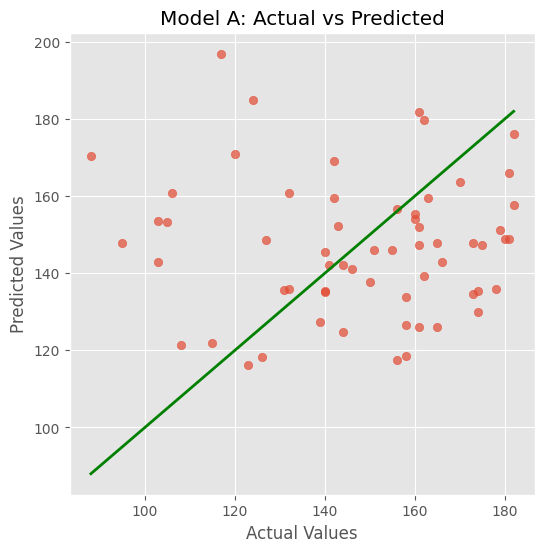

In [ ]:
# Model A

plt.figure(figsize=(6,6))

plt.scatter(y_test_linear, y_pred_model_a, alpha=0.7)

plt.plot(
    [y_test_linear.min(), y_test_linear.max()],
    [y_test_linear.min(), y_test_linear.max()],
    color= "green",
    linewidth=2
)

plt.title("Model A: Actual vs Predicted")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.show()

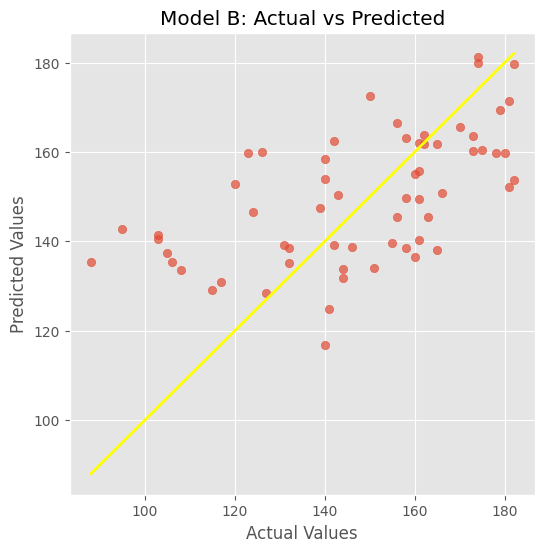

In [ ]:
# Model B

plt.figure(figsize=(6,6))

plt.scatter(y_test_linear, y_pred_model_b, alpha=0.7)

plt.plot(
    [y_test_linear.min(), y_test_linear.max()],
    [y_test_linear.min(), y_test_linear.max()],
    color="yellow",
    linewidth=2
)

plt.title("Model B: Actual vs Predicted")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.show()

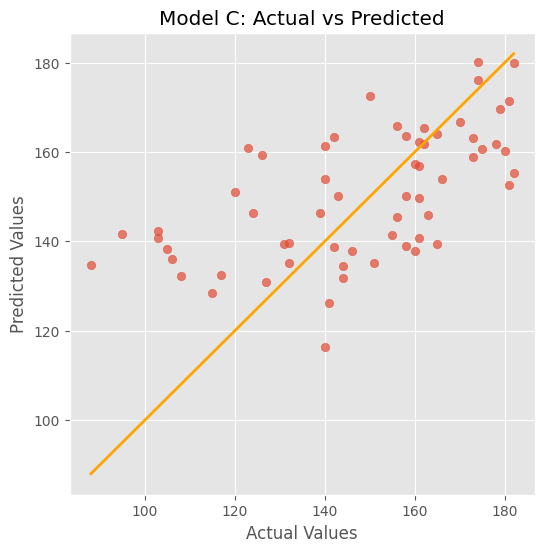

In [ ]:
# Model C

plt.figure(figsize=(6,6))

plt.scatter(y_test_linear, y_pred_model_c, alpha=0.7)

plt.plot(
    [y_test_linear.min(), y_test_linear.max()],
    [y_test_linear.min(), y_test_linear.max()],
    color="orange",
    linewidth=2
)

plt.title("Model C: Actual vs Predicted")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.show()

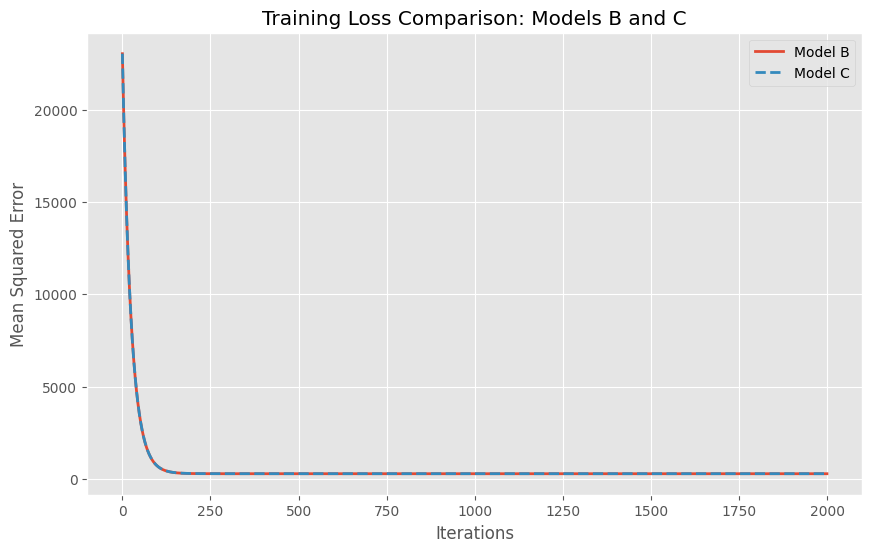

In [ ]:
# 2.8 Visualizing Training Loss

plt.figure(figsize=(10, 6))

plt.plot(
    model_b.loss_history,
    label="Model B",
    linewidth=2,
    linestyle="-"
)

plt.plot(
    model_c.loss_history,
    label="Model C",
    linewidth=2,
    linestyle="--"
)

plt.title("Training Loss Comparison: Models B and C")
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)

plt.show()

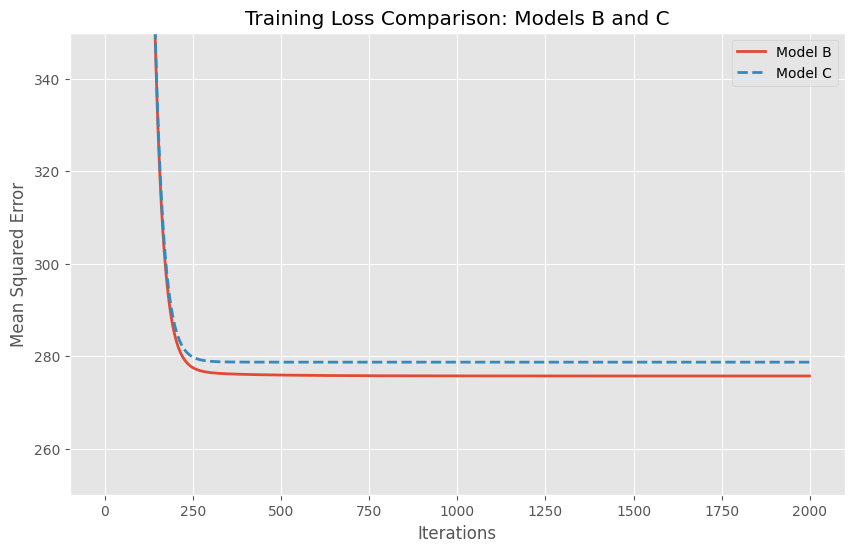

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    model_b.loss_history,
    label="Model B",
    linewidth=2,
    linestyle="-"
)

plt.plot(
    model_c.loss_history,
    label="Model C",
    linewidth=2,
    linestyle="--"
)

plt.title("Training Loss Comparison: Models B and C")
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error")
plt.ylim(250, 350)
plt.legend()
plt.grid(True)

plt.show()

# 2.9 Final Analysis and Interpretation

The three Linear Regression models were successfully implemented from scratch
using Batch Gradient Descent.

### Model A (Baseline)
The baseline model was trained using the original features without
standardization or PCA. It produced the weakest performance because the
features had different scales, making Gradient Descent less efficient.

### Model B (Standardization)
Applying StandardScaler significantly improved the training process and reduced
the prediction error. The model achieved much lower MAE and RMSE values than
Model A, demonstrating the importance of feature scaling.

### Model C (Standardization + PCA)
PCA reduced the number of features while preserving 95% of the data variance.
Although the training loss was slightly higher than Model B, it achieved the
best performance on the test data. This indicates that PCA helped reduce
redundant information and improved the model's generalization ability.

### Conclusion
Among the three models, Model C achieved the best overall performance based on
MAE, RMSE, and R² Score. Therefore, combining Standardization with PCA provided
the most effective Linear Regression model for this dataset.

# Task 3: Build Logistic Regression Model


In [117]:
# 3.1 Building the Logistic Regression Class from Scratch
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, n_iterations=2000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)

        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        for _ in range(self.n_iterations):
            linear_output = np.dot(X, self.weights) + self.bias

            y_probability = self.sigmoid(linear_output)

            error = y_probability - y

            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            epsilon = 1e-15

            y_probability = np.clip(
                y_probability,
                epsilon,
                1 - epsilon
            )

            binary_cross_entropy = -np.mean(
                y * np.log(y_probability)
                + (1 - y) * np.log(1 - y_probability)
            )

            self.loss_history.append(binary_cross_entropy)

        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)

        linear_output = np.dot(X, self.weights) + self.bias

        return self.sigmoid(linear_output)

    def predict(self, X, threshold=0.5):
        probabilities = self.predict_proba(X)

        return (probabilities >= threshold).astype(int)

In [116]:
# 3.2 Model A: Baseline Logistic Regression
model_a_logistic = LogisticRegressionScratch(
    learning_rate=0.00001,
    n_iterations=20000
)

model_a_logistic.fit(
    X_train_logistic,
    y_train_logistic
)

y_pred_model_a_logistic = model_a_logistic.predict(
    X_test_logistic
)

y_prob_model_a_logistic = model_a_logistic.predict_proba(
    X_test_logistic
)

print("Number of Weights:", len(model_a_logistic.weights))
print("Bias:", model_a_logistic.bias)
print("First Training Loss:", model_a_logistic.loss_history[0])
print("Final Training Loss:", model_a_logistic.loss_history[-1])
print("First 10 Predictions:", y_pred_model_a_logistic[:10])
print("First 10 Actual Values:", y_test_logistic.to_numpy()[:10])

Number of Weights: 20
Bias: 0.00091274662128329
First Training Loss: 0.6931471805599453
Final Training Loss: 0.5858693358193445
First 10 Predictions: [0 1 0 0 0 1 0 1 0 0]
First 10 Actual Values: [0 0 0 0 0 0 0 0 1 0]


In [118]:
# 3.3 Model B: Logistic Regression with Standardization
model_b_logistic = LogisticRegressionScratch(
    learning_rate=0.01,
    n_iterations=2000
)

model_b_logistic.fit(
    X_train_logistic_scaled,
    y_train_logistic
)

y_pred_model_b_logistic = model_b_logistic.predict(
    X_test_logistic_scaled
)

y_prob_model_b_logistic = model_b_logistic.predict_proba(
    X_test_logistic_scaled
)

print("Number of Weights:", len(model_b_logistic.weights))
print("Bias:", model_b_logistic.bias)
print("First Training Loss:", model_b_logistic.loss_history[0])
print("Final Training Loss:", model_b_logistic.loss_history[-1])
print("First 10 Predictions:", y_pred_model_b_logistic[:10])
print("First 10 Actual Values:", y_test_logistic.to_numpy()[:10])

Number of Weights: 20
Bias: -0.18139030317534813
First Training Loss: 0.6931471805599453
Final Training Loss: 0.338450412269185
First 10 Predictions: [0 1 0 0 0 0 0 0 1 0]
First 10 Actual Values: [0 0 0 0 0 0 0 0 1 0]


In [119]:
# 3.4 Model C: Logistic Regression with Standardization and PCA
model_c_logistic = LogisticRegressionScratch(
    learning_rate=0.01,
    n_iterations=2000
)

model_c_logistic.fit(
    X_train_logistic_pca,
    y_train_logistic
)

y_pred_model_c_logistic = model_c_logistic.predict(
    X_test_logistic_pca
)

y_prob_model_c_logistic = model_c_logistic.predict_proba(
    X_test_logistic_pca
)

print("Number of PCA Components:", X_train_logistic_pca.shape[1])
print("Number of Weights:", len(model_c_logistic.weights))
print("Bias:", model_c_logistic.bias)
print("First Training Loss:", model_c_logistic.loss_history[0])
print("Final Training Loss:", model_c_logistic.loss_history[-1])
print("First 10 Predictions:", y_pred_model_c_logistic[:10])
print("First 10 Actual Values:", y_test_logistic.to_numpy()[:10])

Number of PCA Components: 17
Number of Weights: 17
Bias: -0.2077594425359332
First Training Loss: 0.6931471805599453
Final Training Loss: 0.3513195940801716
First 10 Predictions: [0 1 0 0 0 0 0 0 1 0]
First 10 Actual Values: [0 0 0 0 0 0 0 0 1 0]


In [128]:
# 3.5 Evaluating the Logistic Regression Models

def calculate_classification_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / (tp + tn + fp + fn)

    precision = tp / (tp + fp) if (tp + fp) != 0 else 0

    recall = tp / (tp + fn) if (tp + fn) != 0 else 0

    f1_score = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) != 0
        else 0
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1_score,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    }


metrics_model_a = calculate_classification_metrics(
    y_test_logistic,
    y_pred_model_a_logistic
)

metrics_model_b = calculate_classification_metrics(
    y_test_logistic,
    y_pred_model_b_logistic
)

metrics_model_c = calculate_classification_metrics(
    y_test_logistic,
    y_pred_model_c_logistic
)


all_metrics = {
    "Model A": metrics_model_a,
    "Model B": metrics_model_b,
    "Model C": metrics_model_c
}


for model_name, metrics in all_metrics.items():
    print(f"\n{model_name} Metrics")

    for metric, value in metrics.items():

        if metric in ["TP", "TN", "FP", "FN"]:
            print(f"{metric}: {int(value)}")

        else:
            print(f"{metric}: {value:.4f}")


Model A Metrics
Accuracy: 0.7705
Precision: 0.7692
Recall: 0.7143
F1-Score: 0.7407
TP: 20
TN: 27
FP: 6
FN: 8

Model B Metrics
Accuracy: 0.8525
Precision: 0.8276
Recall: 0.8571
F1-Score: 0.8421
TP: 24
TN: 28
FP: 5
FN: 4

Model C Metrics
Accuracy: 0.8525
Precision: 0.8276
Recall: 0.8571
F1-Score: 0.8421
TP: 24
TN: 28
FP: 5
FN: 4


In [129]:
# 3.6 Comparing the Logistic Regression Models
comparison_logistic = pd.DataFrame({
    "Model": [
        "Model A (Baseline)",
        "Model B (Standardization)",
        "Model C (Standardization + PCA)"
    ],
    "Accuracy": [
        metrics_model_a["Accuracy"],
        metrics_model_b["Accuracy"],
        metrics_model_c["Accuracy"]
    ],
    "Precision": [
        metrics_model_a["Precision"],
        metrics_model_b["Precision"],
        metrics_model_c["Precision"]
    ],
    "Recall": [
        metrics_model_a["Recall"],
        metrics_model_b["Recall"],
        metrics_model_c["Recall"]
    ],
    "F1-Score": [
        metrics_model_a["F1-Score"],
        metrics_model_b["F1-Score"],
        metrics_model_c["F1-Score"]
    ]
})

comparison_logistic = comparison_logistic.round(4)

comparison_logistic


,Model,Accuracy,Precision,Recall,F1-Score
0,Model A (Baseline),0.7705,0.7692,0.7143,0.7407
1,Model B (Standardization),0.8525,0.8276,0.8571,0.8421
2,Model C (Standardization + PCA),0.8525,0.8276,0.8571,0.8421


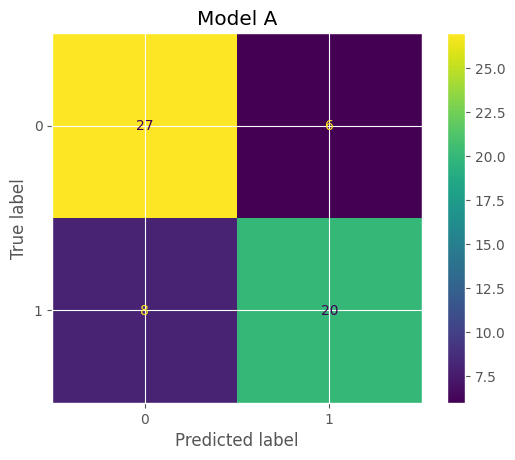

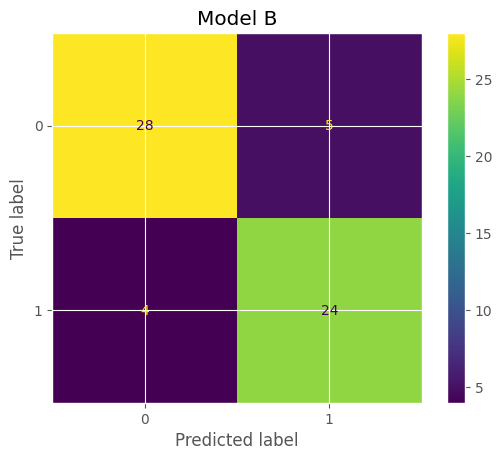

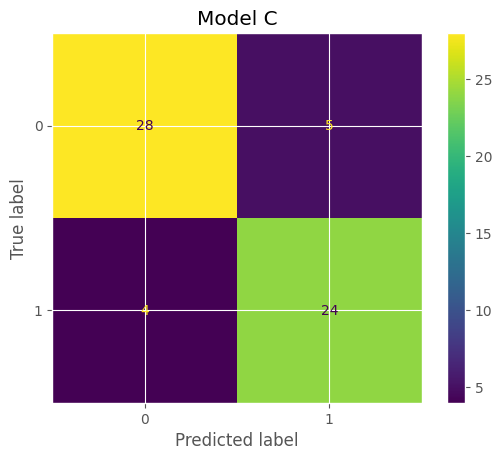

In [130]:
# 3.7 Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def create_confusion_matrix(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    return np.array([
        [tn, fp],
        [fn, tp]
    ])


confusion_matrices = [
    ("Model A", create_confusion_matrix(y_test_logistic, y_pred_model_a_logistic)),
    ("Model B", create_confusion_matrix(y_test_logistic, y_pred_model_b_logistic)),
    ("Model C", create_confusion_matrix(y_test_logistic, y_pred_model_c_logistic))
]


for title, cm in confusion_matrices:

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["0", "1"]
    ).plot()

    plt.title(title)
    plt.show()

/tmp/ipykernel_2838/2175108684.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(tpr_sorted, fpr_sorted)


Model A AUC: 0.8074
Model B AUC: 0.9545
Model C AUC: 0.9416


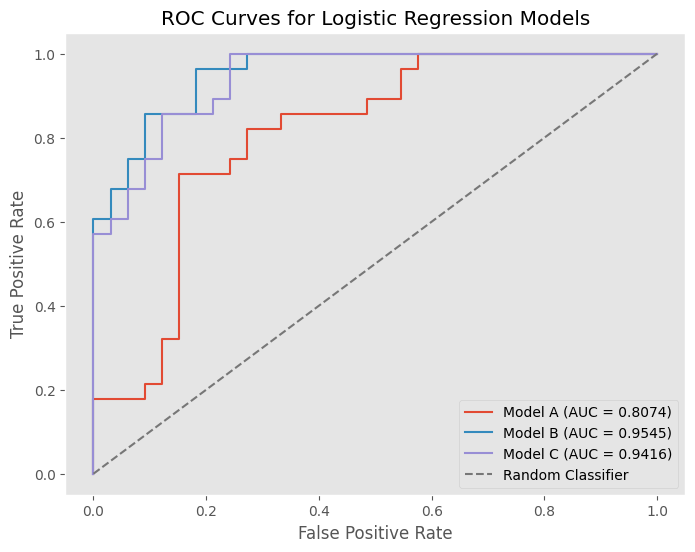

In [131]:
# 3.8 ROC Curve

def calculate_roc_curve(y_true, y_prob):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    thresholds = np.concatenate((
        [np.inf],
        np.sort(np.unique(y_prob))[::-1],
        [-np.inf]
    ))

    tpr_values = []
    fpr_values = []

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)

        tp = np.sum((y_true == 1) & (y_pred == 1))
        tn = np.sum((y_true == 0) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))

        tpr = tp / (tp + fn) if (tp + fn) != 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) != 0 else 0

        tpr_values.append(tpr)
        fpr_values.append(fpr)

    return np.array(fpr_values), np.array(tpr_values)


def calculate_auc(fpr, tpr):
    sorted_indices = np.argsort(fpr)

    fpr_sorted = fpr[sorted_indices]
    tpr_sorted = tpr[sorted_indices]

    return np.trapz(tpr_sorted, fpr_sorted)


fpr_a, tpr_a = calculate_roc_curve(
    y_test_logistic,
    y_prob_model_a_logistic
)

fpr_b, tpr_b = calculate_roc_curve(
    y_test_logistic,
    y_prob_model_b_logistic
)

fpr_c, tpr_c = calculate_roc_curve(
    y_test_logistic,
    y_prob_model_c_logistic
)


auc_a = calculate_auc(fpr_a, tpr_a)
auc_b = calculate_auc(fpr_b, tpr_b)
auc_c = calculate_auc(fpr_c, tpr_c)


print("Model A AUC:", round(auc_a, 4))
print("Model B AUC:", round(auc_b, 4))
print("Model C AUC:", round(auc_c, 4))


plt.figure(figsize=(8, 6))

plt.plot(
    fpr_a,
    tpr_a,
    label=f"Model A (AUC = {auc_a:.4f})"
)

plt.plot(
    fpr_b,
    tpr_b,
    label=f"Model B (AUC = {auc_b:.4f})"
)

plt.plot(
    fpr_c,
    tpr_c,
    label=f"Model C (AUC = {auc_c:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Logistic Regression Models")
plt.legend()
plt.grid()
plt.show()


# 3.9 Final Analysis
-Three Logistic Regression models were implemented and compared.

-Model A was trained using the original features and achieved the lowest performance among the three models.


-Applying Standardization in Model B significantly improved all evaluation metrics, including Accuracy, Precision, Recall, F1-Score, and AUC. Model B achieved the best overall performance with an AUC of 0.9545.


-Model C combined Standardization with PCA. Although PCA reduced the number of features from 20 to 17 components, the classification performance remained very close to Model B. This indicates that PCA successfully reduced the dimensionality while preserving most of the useful information.


-Overall, Model B achieved the highest predictive performance, while Model C provided a simpler model with fewer features and only a slight reduction in AUC.

# Task 4: Overall Comparison


In [133]:
# 4.1 Custom Models Performance Summary

custom_models_summary = pd.DataFrame({
    "Task": [
        "Linear Regression",
        "Linear Regression",
        "Linear Regression",
        "Logistic Regression",
        "Logistic Regression",
        "Logistic Regression"
    ],

    "Model": [
        "Model A (Baseline)",
        "Model B (Standardization)",
        "Model C (Standardization + PCA)",
        "Model A (Baseline)",
        "Model B (Standardization)",
        "Model C (Standardization + PCA)"
    ],

    "MAE": [
        23.8274,
        16.1313,
        15.8271,
        np.nan,
        np.nan,
        np.nan
    ],

    "RMSE": [
        30.5658,
        19.8683,
        19.6307,
        np.nan,
        np.nan,
        np.nan
    ],

    "R2": [
        -0.5811,
        0.3319,
        0.3478,
        np.nan,
        np.nan,
        np.nan
    ],

    "Accuracy": [
        np.nan,
        np.nan,
        np.nan,
        metrics_model_a["Accuracy"],
        metrics_model_b["Accuracy"],
        metrics_model_c["Accuracy"]
    ],

    "Precision": [
        np.nan,
        np.nan,
        np.nan,
        metrics_model_a["Precision"],
        metrics_model_b["Precision"],
        metrics_model_c["Precision"]
    ],

    "Recall": [
        np.nan,
        np.nan,
        np.nan,
        metrics_model_a["Recall"],
        metrics_model_b["Recall"],
        metrics_model_c["Recall"]
    ],

    "F1-Score": [
        np.nan,
        np.nan,
        np.nan,
        metrics_model_a["F1-Score"],
        metrics_model_b["F1-Score"],
        metrics_model_c["F1-Score"]
    ]
})

custom_models_summary = custom_models_summary.round(4)

custom_models_summary

,Task,Model,MAE,RMSE,R2,Accuracy,Precision,Recall,F1-Score
0,Linear Regression,Model A (Baseline),23.8274,30.5658,-0.5811,NaN,NaN,NaN,NaN
1,Linear Regression,Model B (Standardization),16.1313,19.8683,0.3319,NaN,NaN,NaN,NaN
2,Linear Regression,Model C (Standardization + PCA),15.8271,19.6307,0.3478,NaN,NaN,NaN,NaN
3,Logistic Regression,Model A (Baseline),NaN,NaN,NaN,0.7705,0.7692,0.7143,0.7407
4,Logistic Regression,Model B (Standardization),NaN,NaN,NaN,0.8525,0.8276,0.8571,0.8421
5,Logistic Regression,Model C (Standardization + PCA),NaN,NaN,NaN,0.8525,0.8276,0.8571,0.8421


# 4.2 Impact of Preprocessing
### Effect of Standardization

Standardization had a significant positive impact on both Linear Regression and Logistic Regression models.

For Linear Regression, scaling the features reduced both MAE and RMSE while increasing the R² score. This indicates that the model was able to learn more effectively after all features were placed on a similar scale.

For Logistic Regression, Standardization accelerated the optimization process and improved the classification performance. The Accuracy increased from 77.05% in the baseline model to 85.25% after scaling. Precision, Recall, F1-Score, and AUC also improved considerably.

---

### Effect of PCA

Principal Component Analysis (PCA) reduced the dimensionality of the dataset while preserving most of the useful information.

For Linear Regression, PCA slightly improved the overall regression performance.

For Logistic Regression, PCA reduced the number of features from 20 to 17 principal components while maintaining the same Accuracy, Precision, Recall, and F1-Score as the Standardization model. Although the AUC decreased slightly, the reduction was minimal.

---

### Trade-off Between Dimensionality Reduction and Performance

PCA simplified the models by reducing the number of input features.

Although a small amount of information was lost, the predictive performance remained almost unchanged. This demonstrates that PCA can reduce model complexity while maintaining strong predictive performance.

In [134]:
# 4.3 Scikit-learn Linear Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Model A: Baseline
sklearn_linear_a = LinearRegression()

sklearn_linear_a.fit(
    X_train_linear,
    y_train_linear
)

y_pred_sklearn_linear_a = sklearn_linear_a.predict(
    X_test_linear
)


# Model B: Standardization
sklearn_linear_b = LinearRegression()

sklearn_linear_b.fit(
    X_train_linear_scaled,
    y_train_linear
)

y_pred_sklearn_linear_b = sklearn_linear_b.predict(
    X_test_linear_scaled
)


# Model C: Standardization + PCA
sklearn_linear_c = LinearRegression()

sklearn_linear_c.fit(
    X_train_linear_pca,
    y_train_linear
)

y_pred_sklearn_linear_c = sklearn_linear_c.predict(
    X_test_linear_pca
)


def evaluate_sklearn_linear(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }


sklearn_linear_metrics_a = evaluate_sklearn_linear(
    y_test_linear,
    y_pred_sklearn_linear_a
)

sklearn_linear_metrics_b = evaluate_sklearn_linear(
    y_test_linear,
    y_pred_sklearn_linear_b
)

sklearn_linear_metrics_c = evaluate_sklearn_linear(
    y_test_linear,
    y_pred_sklearn_linear_c
)


sklearn_linear_comparison = pd.DataFrame({
    "Model": [
        "Model A (Baseline)",
        "Model B (Standardization)",
        "Model C (Standardization + PCA)"
    ],

    "MAE": [
        sklearn_linear_metrics_a["MAE"],
        sklearn_linear_metrics_b["MAE"],
        sklearn_linear_metrics_c["MAE"]
    ],

    "RMSE": [
        sklearn_linear_metrics_a["RMSE"],
        sklearn_linear_metrics_b["RMSE"],
        sklearn_linear_metrics_c["RMSE"]
    ],

    "R2": [
        sklearn_linear_metrics_a["R2"],
        sklearn_linear_metrics_b["R2"],
        sklearn_linear_metrics_c["R2"]
    ]
})

sklearn_linear_comparison = sklearn_linear_comparison.round(4)

sklearn_linear_comparison


,Model,MAE,RMSE,R2
0,Model A (Baseline),16.1325,19.8351,0.3342
1,Model B (Standardization),16.1325,19.8351,0.3342
2,Model C (Standardization + PCA),15.8249,19.5829,0.3510


In [135]:
# 4.4 Custom vs. Scikit-learn Linear Regression
linear_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Standardization",
        "Standardization + PCA"
    ],

    "Custom MAE": [
        23.8274,
        16.1313,
        15.8271
    ],

    "Sklearn MAE": [
        sklearn_linear_metrics_a["MAE"],
        sklearn_linear_metrics_b["MAE"],
        sklearn_linear_metrics_c["MAE"]
    ],

    "Custom RMSE": [
        30.5658,
        19.8683,
        19.6307
    ],

    "Sklearn RMSE": [
        sklearn_linear_metrics_a["RMSE"],
        sklearn_linear_metrics_b["RMSE"],
        sklearn_linear_metrics_c["RMSE"]
    ],

    "Custom R²": [
        -0.5811,
        0.3319,
        0.3478
    ],

    "Sklearn R²": [
        sklearn_linear_metrics_a["R2"],
        sklearn_linear_metrics_b["R2"],
        sklearn_linear_metrics_c["R2"]
    ]
})

linear_comparison = linear_comparison.round(4)

linear_comparison


,Model,Custom MAE,Sklearn MAE,Custom RMSE,Sklearn RMSE,Custom R²,Sklearn R²
0,Baseline,23.8274,16.1325,30.5658,19.8351,-0.5811,0.3342
1,Standardization,16.1313,16.1325,19.8683,19.8351,0.3319,0.3342
2,Standardization + PCA,15.8271,15.8249,19.6307,19.5829,0.3478,0.3510


In [136]:
# 4.5 Scikit-learn Logistic Regression Models
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# Model A: Baseline
sklearn_logistic_a = LogisticRegression(
    max_iter=5000,
    random_state=42
)

sklearn_logistic_a.fit(
    X_train_logistic,
    y_train_logistic
)

y_pred_sklearn_logistic_a = sklearn_logistic_a.predict(
    X_test_logistic
)


# Model B: Standardization
sklearn_logistic_b = LogisticRegression(
    max_iter=5000,
    random_state=42
)

sklearn_logistic_b.fit(
    X_train_logistic_scaled,
    y_train_logistic
)

y_pred_sklearn_logistic_b = sklearn_logistic_b.predict(
    X_test_logistic_scaled
)


# Model C: Standardization + PCA
sklearn_logistic_c = LogisticRegression(
    max_iter=5000,
    random_state=42
)

sklearn_logistic_c.fit(
    X_train_logistic_pca,
    y_train_logistic
)

y_pred_sklearn_logistic_c = sklearn_logistic_c.predict(
    X_test_logistic_pca
)


def evaluate_sklearn_logistic(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }


sklearn_logistic_metrics_a = evaluate_sklearn_logistic(
    y_test_logistic,
    y_pred_sklearn_logistic_a
)

sklearn_logistic_metrics_b = evaluate_sklearn_logistic(
    y_test_logistic,
    y_pred_sklearn_logistic_b
)

sklearn_logistic_metrics_c = evaluate_sklearn_logistic(
    y_test_logistic,
    y_pred_sklearn_logistic_c
)


sklearn_logistic_comparison = pd.DataFrame({
    "Model": [
        "Model A (Baseline)",
        "Model B (Standardization)",
        "Model C (Standardization + PCA)"
    ],

    "Accuracy": [
        sklearn_logistic_metrics_a["Accuracy"],
        sklearn_logistic_metrics_b["Accuracy"],
        sklearn_logistic_metrics_c["Accuracy"]
    ],

    "Precision": [
        sklearn_logistic_metrics_a["Precision"],
        sklearn_logistic_metrics_b["Precision"],
        sklearn_logistic_metrics_c["Precision"]
    ],

    "Recall": [
        sklearn_logistic_metrics_a["Recall"],
        sklearn_logistic_metrics_b["Recall"],
        sklearn_logistic_metrics_c["Recall"]
    ],

    "F1-Score": [
        sklearn_logistic_metrics_a["F1-Score"],
        sklearn_logistic_metrics_b["F1-Score"],
        sklearn_logistic_metrics_c["F1-Score"]
    ]
})

sklearn_logistic_comparison = sklearn_logistic_comparison.round(4)

sklearn_logistic_comparison


,Model,Accuracy,Precision,Recall,F1-Score
0,Model A (Baseline),0.8689,0.8333,0.8929,0.8621
1,Model B (Standardization),0.8525,0.8276,0.8571,0.8421
2,Model C (Standardization + PCA),0.8361,0.8462,0.7857,0.8148


In [137]:
# 4.6 Custom vs. Scikit-learn Logistic Regression
logistic_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Standardization",
        "Standardization + PCA"
    ],

    "Custom Accuracy": [
        metrics_model_a["Accuracy"],
        metrics_model_b["Accuracy"],
        metrics_model_c["Accuracy"]
    ],

    "Sklearn Accuracy": [
        sklearn_logistic_metrics_a["Accuracy"],
        sklearn_logistic_metrics_b["Accuracy"],
        sklearn_logistic_metrics_c["Accuracy"]
    ],

    "Custom Precision": [
        metrics_model_a["Precision"],
        metrics_model_b["Precision"],
        metrics_model_c["Precision"]
    ],

    "Sklearn Precision": [
        sklearn_logistic_metrics_a["Precision"],
        sklearn_logistic_metrics_b["Precision"],
        sklearn_logistic_metrics_c["Precision"]
    ],

    "Custom Recall": [
        metrics_model_a["Recall"],
        metrics_model_b["Recall"],
        metrics_model_c["Recall"]
    ],

    "Sklearn Recall": [
        sklearn_logistic_metrics_a["Recall"],
        sklearn_logistic_metrics_b["Recall"],
        sklearn_logistic_metrics_c["Recall"]
    ],

    "Custom F1-Score": [
        metrics_model_a["F1-Score"],
        metrics_model_b["F1-Score"],
        metrics_model_c["F1-Score"]
    ],

    "Sklearn F1-Score": [
        sklearn_logistic_metrics_a["F1-Score"],
        sklearn_logistic_metrics_b["F1-Score"],
        sklearn_logistic_metrics_c["F1-Score"]
    ]
})

logistic_comparison = logistic_comparison.round(4)

logistic_comparison

,Model,Custom Accuracy,Sklearn Accuracy,Custom Precision,Sklearn Precision,Custom Recall,Sklearn Recall,Custom F1-Score,Sklearn F1-Score
0,Baseline,0.7705,0.8689,0.7692,0.8333,0.7143,0.8929,0.7407,0.8621
1,Standardization,0.8525,0.8525,0.8276,0.8276,0.8571,0.8571,0.8421,0.8421
2,Standardization + PCA,0.8525,0.8361,0.8276,0.8462,0.8571,0.7857,0.8421,0.8148


# 4.7 Overall Analysis and Discussion
## Performance Comparison

The custom implementations produced results that were generally close to the scikit-learn implementations.

For Linear Regression, the largest difference appeared in the baseline model because the custom implementation used Gradient Descent optimization, while scikit-learn computes the optimal solution analytically. After applying Standardization and PCA, the performance gap became much smaller.

For Logistic Regression, the custom implementation achieved competitive performance. The Standardization model produced results identical to the scikit-learn implementation, while small differences appeared in the Baseline and PCA models due to differences in optimization algorithms and default regularization.

---

## Validation of the Custom Implementation

The close agreement between the custom models and the scikit-learn models confirms that the custom implementations were correctly developed.

Although small performance differences exist, they are expected because the library implementation uses highly optimized numerical techniques and built-in regularization.

---

## Strengths and Weaknesses

**Strengths**

- Complete implementation from scratch.
- Good agreement with scikit-learn models.
- Clear improvement after preprocessing.
- Easy to understand and modify.

**Weaknesses**

- Slower training than the optimized library implementation.
- Sensitive to the learning rate and number of iterations.
- Does not include advanced optimization methods available in scikit-learn.

# 4.8 Observations and Recommendations
## Observations

- Standardization significantly improved the performance of the custom models.
- PCA successfully reduced the dimensionality while maintaining competitive performance.
- The scikit-learn implementations were generally more stable because they use optimized algorithms.
- The custom models achieved results that were very close to the library implementations, demonstrating that the algorithms were implemented correctly.

---

## Recommendations

- Use Standardization before training Gradient Descent models.
- Apply PCA when reducing dimensionality is important while maintaining acceptable performance.
- Use scikit-learn models in real-world applications because they are faster and more optimized.
- Custom implementations are valuable for understanding how machine learning algorithms work internally.